# Chapter 9 - k-Means Clustering

## Iris flower clustering with k = 3

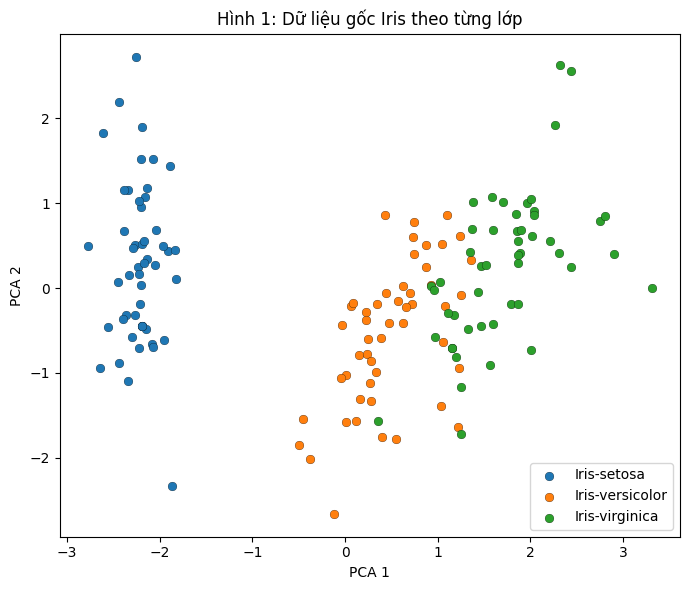

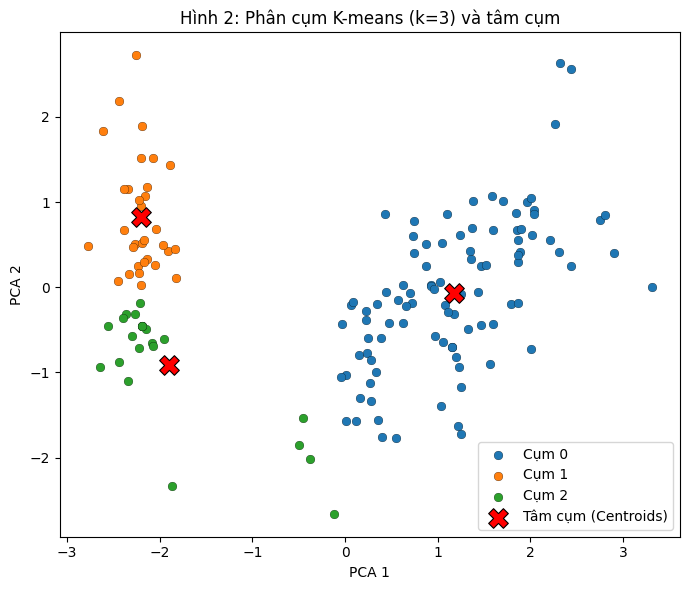

In [1]:
import pandas as pd                      # Thư viện pandas dùng để xử lý bảng dữ liệu
from sklearn.preprocessing import StandardScaler   # StandardScaler dùng để chuẩn hóa dữ liệu
from sklearn.cluster import KMeans                 # Thuật toán K-means
from sklearn.decomposition import PCA              # PCA dùng để giảm chiều dữ liệu
import matplotlib.pyplot as plt                    # matplotlib dùng để vẽ đồ thị

# ============================================================
# 1. ĐỌC DỮ LIỆU IRIS
# ============================================================

df = pd.read_csv("iris.csv")             # Đọc file iris.csv vào DataFrame 'df'

# ============================================================
# 2. XÁC ĐỊNH CỘT NHÃN LỚP (Species)
# ============================================================

label_col = "Species"

# ============================================================
# 3. CHUẨN BỊ DỮ LIỆU SỐ CHO K-MEANS
# ============================================================

# Loại bỏ cột Id và Species khỏi dữ liệu để phân cụm
X = df.drop(columns=["Id", "Species"])

# ============================================================
# 4. CHUẨN HOÁ DỮ LIỆU
# ============================================================

scaler = StandardScaler()                # Tạo đối tượng chuẩn hóa StandardScaler
X_scaled = scaler.fit_transform(X)       # Chuẩn hóa dữ liệu (mean=0, std=1)

# ============================================================
# 5. PHÂN CỤM K-MEANS (k=3)
# ============================================================

kmeans = KMeans(n_clusters=3, random_state=42)   # Tạo mô hình K-means với 3 cụm
clusters = kmeans.fit_predict(X_scaled)          # Gán mỗi điểm vào một cụm (0,1,2)

# ============================================================
# 6. GIẢM CHIỀU DỮ LIỆU BẰNG PCA
# ============================================================

pca = PCA(n_components=2)               # PCA giảm dữ liệu từ 4 chiều → 2 chiều
X_pca = pca.fit_transform(X_scaled)     # Biến đổi dữ liệu thành 2 thành phần PCA

# Lấy tọa độ tâm cụm trong không gian chuẩn hóa
centers_scaled = kmeans.cluster_centers_      # Tọa độ tâm cụm trong không gian đã chuẩn hóa

# Chuyển tâm cụm sang không gian PCA 2D để vẽ
centers_pca = pca.transform(centers_scaled)

# ============================================================
# 7. HÌNH 1 — VẼ DỮ LIỆU GỐC THEO LỚP (CÓ CHÚ THÍCH)
# ============================================================

plt.figure(figsize=(7,6))                     # Tạo khung hình kích thước 7x6 inch

class_codes = df[label_col].astype("category").cat.codes      # Mã hóa tên lớp thành số (0-1-2)
class_names = df[label_col].astype("category").cat.categories # Danh sách tên lớp

for code, name in enumerate(class_names):     # Lặp qua từng mã lớp và tên lớp
    plt.scatter(
        X_pca[class_codes == code, 0],         # Trục X của điểm thuộc lớp đó
        X_pca[class_codes == code, 1],         # Trục Y của điểm thuộc lớp đó
        label=name,                            # Tên lớp dùng để hiển thị trong legend
        s=40,                                  # Kích thước điểm
        edgecolor='k',                         # Viền màu đen
        linewidth=0.2                          # Độ dày viền
    )

plt.xlabel("PCA 1")                            # Nhãn trục X
plt.ylabel("PCA 2")                            # Nhãn trục Y
plt.title("Hình 1: Dữ liệu gốc Iris theo từng lớp")   # Tiêu đề biểu đồ
plt.legend()                                    # Hiển thị chú thích (legend)
plt.tight_layout()                              # Canh lề cho đẹp
plt.show()                                      # Hiển thị hình

# ============================================================
# 8. HÌNH 2 — VẼ K-MEANS + TÂM CỤM
# ============================================================

plt.figure(figsize=(7,6))                      # Tạo hình mới kích thước 7x6

for cluster_id in range(3):                    # Lặp qua 3 cụm (0,1,2)
    plt.scatter(
        X_pca[clusters == cluster_id, 0],        # X của các điểm thuộc cụm cluster_id
        X_pca[clusters == cluster_id, 1],        # Y của các điểm thuộc cụm cluster_id
        label=f"Cụm {cluster_id}",               # Tên trong legend
        s=40,                                    # Kích thước điểm
        edgecolor='k',                           # Viền đen
        linewidth=0.2
    )

# Vẽ tâm cụm màu đỏ, đánh dấu bằng chữ X
plt.scatter(
    centers_pca[:, 0],                        # Tọa độ PCA trục X của tâm cụm
    centers_pca[:, 1],                        # Tọa độ PCA trục Y của tâm cụm
    marker='X',                               # Marker hình chữ X
    s=200,                                    # Kích thước lớn để dễ thấy
    color='red',                              # Màu đỏ
    edgecolor='k',                            # Viền đen
    linewidth=0.8,
    label='Tâm cụm (Centroids)'               # Ghi trong legend
)

plt.xlabel("PCA 1")                            # Nhãn trục X
plt.ylabel("PCA 2")                            # Nhãn trục Y
plt.title("Hình 2: Phân cụm K-means (k=3) và tâm cụm")  # Tiêu đề
plt.legend()                                   # Hiển thị chú thích
plt.tight_layout()                             # Canh lề
plt.show()                                     # Hiển thị hình

## Elbow Method

k	WCSS
1	600.0000
2	223.7320
3	140.9658
4	114.6179
5	91.2954
6	81.7566
7	71.3198
8	62.6518
9	55.2618
10	50.6232

------------------------------------
ĐỀ XUẤT GIÁ TRỊ k (tự động):
------------------------------------
- k theo giảm mạnh nhất ban đầu: 1
- k theo tỷ lệ giảm lớn nhất (elbow gần đúng): 2
------------------------------------


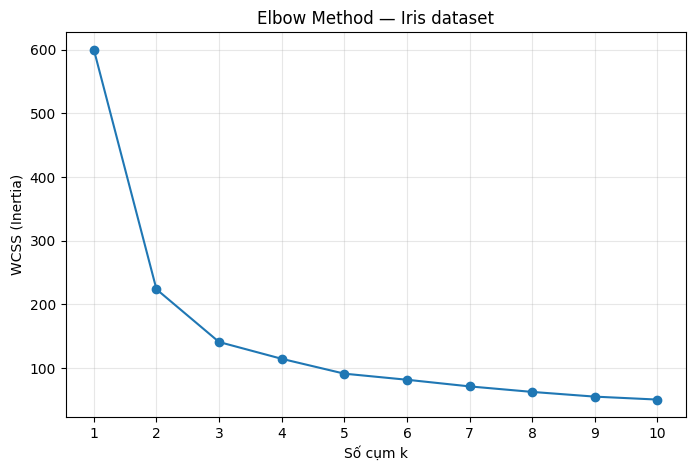

In [2]:
# Elbow Method + đề xuất giá trị k cho dữ liệu Iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# -------------------------
# 1. Load dữ liệu
# -------------------------
df = pd.read_csv("iris.csv")

# Bỏ cột Id nếu có, và bỏ cột nhãn Species
drop_cols = []
if "Id" in df.columns:
    drop_cols.append("Id")

label_col = None
for col in df.columns:
    if df[col].dtype == "object" and col.lower() in ("species", "class"):
        label_col = col
        drop_cols.append(col)
        break

X = df.drop(columns=drop_cols) if drop_cols else df.copy()

# -------------------------
# 2. Chuẩn hóa dữ liệu
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 3. Tính WCSS cho các giá trị k
# -------------------------
k_values = range(1, 11)
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# -------------------------
# 4. In bảng WCSS
# -------------------------
print("k\tWCSS")
for k, val in zip(k_values, wcss):
    print(f"{k}\t{val:.4f}")

# -------------------------
# 5. Tính độ giảm để đề xuất k
# -------------------------
drops = np.diff(wcss)         # độ giảm WCSS
drops_ratio = -drops / wcss[:-1]   # tỷ lệ giảm

# đề xuất k theo các tiêu chí
k_max_drop = np.argmax(drops_ratio[1:]) + 2  
# (dùng từ k=2 trở lên, +2 để bù index)

# đề xuất k theo giảm mạnh đầu tiên (largest drop)
k_largest_drop = np.argmax(np.abs(drops)) + 1

# -------------------------
# 6. In đề xuất giá trị k
# -------------------------
print("\n------------------------------------")
print("ĐỀ XUẤT GIÁ TRỊ k (tự động):")
print("------------------------------------")
print(f"- k theo giảm mạnh nhất ban đầu: {k_largest_drop}")
print(f"- k theo tỷ lệ giảm lớn nhất (elbow gần đúng): {k_max_drop}")
print("------------------------------------")

# -------------------------
# 7. Vẽ biểu đồ Elbow
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o')
plt.xticks(k_values)
plt.xlabel("Số cụm k")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method — Iris dataset")
plt.grid(alpha=0.3)
plt.show()


## Silhouette Method

k =  2  -> Silhouette score = 0.5802
k =  3  -> Silhouette score = 0.4590
k =  4  -> Silhouette score = 0.3853
k =  5  -> Silhouette score = 0.3473
k =  6  -> Silhouette score = 0.3407
k =  7  -> Silhouette score = 0.3288
k =  8  -> Silhouette score = 0.3404
k =  9  -> Silhouette score = 0.3427
k = 10  -> Silhouette score = 0.3404

ĐỀ XUẤT: k tối ưu theo Silhouette score = 2  (score = 0.5802)



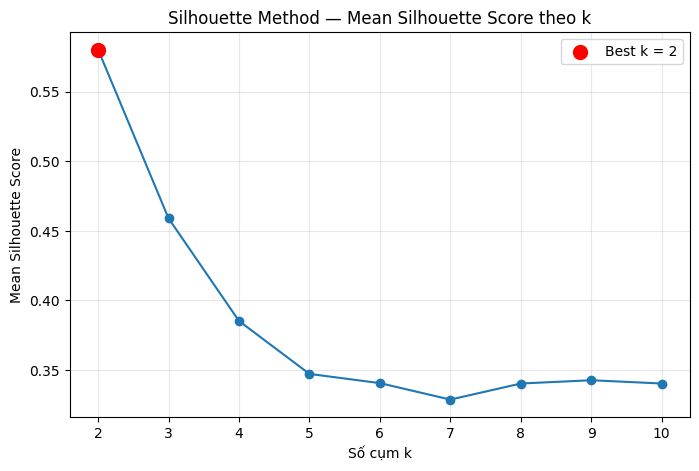

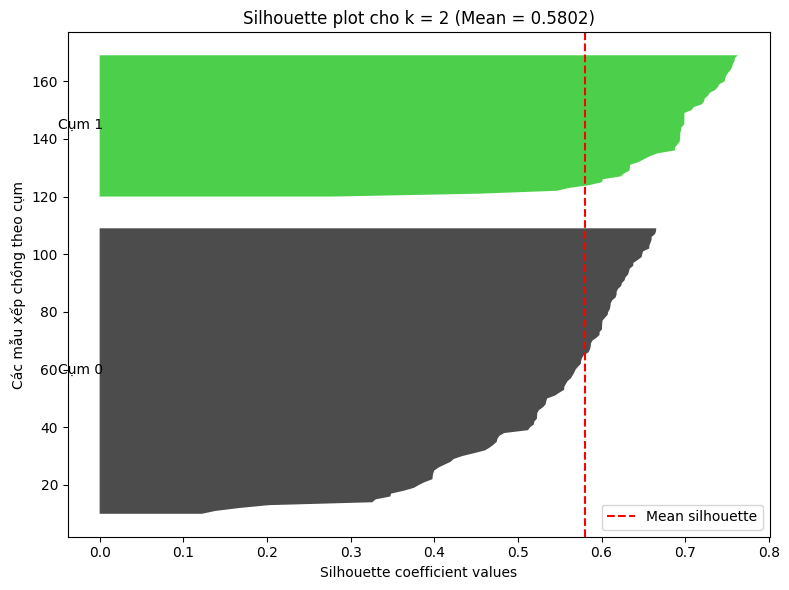

In [3]:
# Silhouette Method cho dữ liệu Iris
# 1) Tính Silhouette score cho các k khác nhau
# 2) Vẽ đồ thị Silhouette score vs k
# 3) Vẽ silhouette plot chi tiết cho k tốt nhất (k tối ưu theo score)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

# -------------------------
# 1. Load dữ liệu & chuẩn bị
# -------------------------

df = pd.read_csv("iris.csv")

# Nếu có cột Id, loại bỏ; nếu có cột nhãn (Species) cũng loại bỏ cho việc phân cụm
drop_cols = []
if "Id" in df.columns:
    drop_cols.append("Id")

label_col = None
for col in df.columns:
    if df[col].dtype == "object" and col.lower() in ("species", "class"):
        label_col = col
        drop_cols.append(col)
        break

X = df.drop(columns=drop_cols) if drop_cols else df.copy()

# Chuẩn hoá dữ liệu trước khi phân cụm
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 2. Thiết lập range k để thử
# -------------------------
k_min = 2
k_max = 10
k_values = list(range(k_min, k_max + 1))

sil_scores = []   # lưu silhouette score trung bình cho mỗi k

# -------------------------
# 3. Tính silhouette score cho từng k
# -------------------------
for k in k_values:
    # Khởi tạo KMeans (chọn n_init ổn định)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    # Tính silhouette score (trung bình)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"k = {k:2d}  -> Silhouette score = {score:.4f}")

# -------------------------
# 4. Đề xuất k tối ưu
# -------------------------
best_idx = int(np.argmax(sil_scores))
best_k = k_values[best_idx]
best_score = sil_scores[best_idx]
print("\n======================================")
print(f"ĐỀ XUẤT: k tối ưu theo Silhouette score = {best_k}  (score = {best_score:.4f})")
print("======================================\n")

# -------------------------
# 5. VẼ đồ thị Silhouette score vs k
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(k_values, sil_scores, marker='o', linestyle='-')
plt.xticks(k_values)
plt.xlabel("Số cụm k")
plt.ylabel("Mean Silhouette Score")
plt.title("Silhouette Method — Mean Silhouette Score theo k")
plt.grid(alpha=0.3)
# đánh dấu k tốt nhất
plt.scatter([best_k], [best_score], color='red', s=100, zorder=5, label=f"Best k = {best_k}")
plt.legend()
plt.show()

# -------------------------
# 6. VẼ Silhouette plot chi tiết cho k tối ưu
# -------------------------
# Nếu user muốn silhouette plot cho k tốt nhất
k = best_k
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

sil_vals = silhouette_samples(X_scaled, cluster_labels)  # silhouette score cho từng mẫu
y_lower = 10  # khoảng đệm ban đầu để vẽ

plt.figure(figsize=(8, 6))
for i in range(k):
    # Lấy silhouette scores của cụm i và sắp xếp chúng
    ith_cluster_silhouette_values = sil_vals[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / k)
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        alpha=0.7
    )
    # ghi nhãn cụm ở giữa khối
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, f"Cụm {i}", va='center')

    y_lower = y_upper + 10  # khoảng trống giữa các cụm trong plot

plt.axvline(x=silhouette_score(X_scaled, cluster_labels), color="red", linestyle="--", label="Mean silhouette")
plt.xlabel("Silhouette coefficient values")
plt.ylabel("Các mẫu xếp chồng theo cụm")
plt.title(f"Silhouette plot cho k = {k} (Mean = {silhouette_score(X_scaled, cluster_labels):.4f})")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# GHI CHÚ:
# - Silhouette score gần +1 => phân cụm tốt (điểm trong cụm gần nhau, tách biệt giữa cụm).
# - Silhouette score ~0 => điểm ở ranh giới giữa hai cụm.
# - Silhouette score < 0 => có điểm bị gán sai cụm.
# - Nên kết hợp Silhouette cùng Elbow và hiểu biết miền (domain knowledge) để chọn k.
# -------------------------


### **Giải thích chi tiết** cho *hình Silhouette plot* (k = 2, Mean = 0.5802).

---

### 🎯 **1. Silhouette plot dùng để làm gì?**

Silhouette plot giúp đánh giá:

* **Độ tách biệt giữa các cụm**
* **Độ chặt chẽ của các điểm trong cùng cụm**

Nó trực quan hơn Silhouette score trung bình, vì nó cho thấy **từng điểm** đóng góp như thế nào.

---

### 🧩 **2. Ý nghĩa của từng phần trong hình**

#### 🔹 **(1) Hai khối màu (xếp chồng theo chiều dọc)**

Vì k = 2 nên có **2 cụm**:

* **Cụm 0** (màu xám)
* **Cụm 1** (màu xanh lá**

Mỗi dải màu tương ứng với tất cả các điểm thuộc cụm đó.

**Chiều cao của mỗi dải = số lượng điểm trong cụm.**

---

#### 🔹 **(2) Chiều ngang = giá trị silhouette của từng điểm**

Silhouette score của mỗi điểm ∈ [-1, 1]:

* **Gần 1** → điểm nằm rất chuẩn trong cụm
* **Gần 0** → điểm nằm ở ranh giới giữa 2 cụm
* **<0** → điểm nằm sai cụm, gần cụm khác hơn chính cụm của mình

**Trong hình:**

* Các điểm chủ yếu có giá trị > 0.4 → phân cụm khá tốt
* Không có điểm nào < 0 → không có điểm bị xếp sai quá rõ

---

#### 🔹 **(3) Đường thẳng đỏ đứng = mean silhouette**

```
Mean Silhouette = 0.5802
```

Đây là **giá trị trung bình** của tất cả điểm.

Ý nghĩa:

* **~0.58 là khá cao**, nghĩa là phân cụm tốt
* Thường >0.5 → cụm tách biệt khá rõ

---

#### 🔹 **(4) Chữ “Cụm 0” và “Cụm 1”**

Ký hiệu rõ cụm tương ứng với từng dải màu.

Giúp đọc biểu đồ dễ dàng, nhất là khi có nhiều cụm.

---

#### 🔹 **(5) Hình dạng cong / dốc của từng dải**

Bạn sẽ thấy các điểm được **sắp xếp tăng dần** theo silhouette score trong mỗi cụm.

Ví dụ:

* Bên trái → điểm có silhouette nhỏ (có thể nằm gần ranh giới cụm)
* Bên phải → điểm có silhouette lớn (ổn định trong cụm)

---

#### 📌 **3. Kết luận từ hình minh họa này**

**✔ k = 2 là một lựa chọn hợp lý cho Iris (theo Silhouette)**

Vì:

* Mean Silhouette ~0.58 (khá cao)
* Không có điểm silhouette âm
* Cụm tách biệt rõ ràng
* Độ “viền” giữa các cụm rõ (khoảng trắng giữa 2 dải)

---

#### 📌 **4. So sánh với thực tế của Iris dataset**

Iris thật có 3 loài → k = 3 về mặt thực tế sinh học.

Nhưng **về mặt hình học trong không gian dữ liệu**:

* Iris-setosa tách biệt hoàn toàn → 1 cụm riêng
* Iris-versicolor và Iris-virginica **chồng lấp nhau** → khó tách biệt bằng K-means

→ Thường Silhouette sẽ đánh giá **k=2 tốt hơn k=3**, vì dữ liệu không tách biệt thật sự theo 3 cụm hình cầu.

(K-means thích dạng tròn (spherical clusters), nhưng Iris-versicolor & virginica không đủ tròn.)

---

#### 🎉 **Tóm tắt ngắn gọn**

| Thành phần            | Ý nghĩa                            |
| --------------------- | ---------------------------------- |
| Dải màu               | Silhouette của từng điểm trong cụm |
| Rộng về bên phải      | Cụm tốt                            |
| Gần 0                 | Ranh giới cụm                      |
| Dưới 0                | Điểm sai cụm                       |
| Đường đỏ              | Silhouette trung bình              |
| Khoảng trắng giữa cụm | Sự tách biệt giữa cụm              |


## Iris flower clustering with k = 2

In [ ]:
import pandas as pd                      # Thư viện pandas dùng để xử lý bảng dữ liệu
from sklearn.preprocessing import StandardScaler   # StandardScaler dùng để chuẩn hóa dữ liệu
from sklearn.cluster import KMeans                 # Thuật toán K-means
from sklearn.decomposition import PCA              # PCA dùng để giảm chiều dữ liệu
import matplotlib.pyplot as plt                    # matplotlib dùng để vẽ đồ thị

# ============================================================
# 1. ĐỌC DỮ LIỆU IRIS
# ============================================================

df = pd.read_csv("iris.csv")             # Đọc file iris.csv vào DataFrame 'df'

# ============================================================
# 2. XÁC ĐỊNH CỘT NHÃN LỚP (Species)
# ============================================================

label_col = "Species"

# ============================================================
# 3. CHUẨN BỊ DỮ LIỆU SỐ CHO K-MEANS
# ============================================================

# Loại bỏ cột Id và Species khỏi dữ liệu để phân cụm
X = df.drop(columns=["Id", "Species"])

# ============================================================
# 4. CHUẨN HOÁ DỮ LIỆU
# ============================================================

scaler = StandardScaler()                # Tạo đối tượng chuẩn hóa StandardScaler
X_scaled = scaler.fit_transform(X)       # Chuẩn hóa dữ liệu (mean=0, std=1)

# ============================================================
# 5. PHÂN CỤM K-MEANS (k=2)
# ============================================================

kmeans = KMeans(n_clusters=2, random_state=42)   # Tạo mô hình K-means với 2 cụm
clusters = kmeans.fit_predict(X_scaled)          # Gán mỗi điểm vào một cụm (0,1)

# ============================================================
# 6. GIẢM CHIỀU DỮ LIỆU BẰNG PCA
# ============================================================

pca = PCA(n_components=2)               # PCA giảm dữ liệu từ 4 chiều → 2 chiều
X_pca = pca.fit_transform(X_scaled)     # Biến đổi dữ liệu thành 2 thành phần PCA

# Lấy tọa độ tâm cụm trong không gian chuẩn hóa
centers_scaled = kmeans.cluster_centers_      # Tọa độ tâm cụm trong không gian đã chuẩn hóa

# Chuyển tâm cụm sang không gian PCA 2D để vẽ
centers_pca = pca.transform(centers_scaled)

# ============================================================
# 7. HÌNH 1 — VẼ DỮ LIỆU GỐC THEO LỚP (CÓ CHÚ THÍCH)
# ============================================================

plt.figure(figsize=(7,6))                     # Tạo khung hình kích thước 7x6 inch

class_codes = df[label_col].astype("category").cat.codes      # Mã hóa tên lớp thành số (0-1-2)
class_names = df[label_col].astype("category").cat.categories # Danh sách tên lớp

for code, name in enumerate(class_names):     # Lặp qua từng mã lớp và tên lớp
    plt.scatter(
        X_pca[class_codes == code, 0],         # Trục X của điểm thuộc lớp đó
        X_pca[class_codes == code, 1],         # Trục Y của điểm thuộc lớp đó
        label=name,                            # Tên lớp dùng để hiển thị trong legend
        s=40,                                  # Kích thước điểm
        edgecolor='k',                         # Viền màu đen
        linewidth=0.2                          # Độ dày viền
    )

plt.xlabel("PCA 1")                            # Nhãn trục X
plt.ylabel("PCA 2")                            # Nhãn trục Y
plt.title("Hình 1: Dữ liệu gốc Iris theo từng lớp")   # Tiêu đề biểu đồ
plt.legend()                                    # Hiển thị chú thích (legend)
plt.tight_layout()                              # Canh lề cho đẹp
plt.show()                                      # Hiển thị hình

# ============================================================
# 8. HÌNH 2 — VẼ K-MEANS + TÂM CỤM
# ============================================================

plt.figure(figsize=(7,6))                      # Tạo hình mới kích thước 7x6

for cluster_id in range(2):                    # Lặp qua 2 cụm (0,1)
    plt.scatter(
        X_pca[clusters == cluster_id, 0],        # X của các điểm thuộc cụm cluster_id
        X_pca[clusters == cluster_id, 1],        # Y của các điểm thuộc cụm cluster_id
        label=f"Cụm {cluster_id}",               # Tên trong legend
        s=40,                                    # Kích thước điểm
        edgecolor='k',                           # Viền đen
        linewidth=0.2
    )

# Vẽ tâm cụm màu đỏ, đánh dấu bằng chữ X
plt.scatter(
    centers_pca[:, 0],                        # Tọa độ PCA trục X của tâm cụm
    centers_pca[:, 1],                        # Tọa độ PCA trục Y của tâm cụm
    marker='X',                               # Marker hình chữ X
    s=200,                                    # Kích thước lớn để dễ thấy
    color='red',                              # Màu đỏ
    edgecolor='k',                            # Viền đen
    linewidth=0.8,
    label='Tâm cụm (Centroids)'               # Ghi trong legend
)

plt.xlabel("PCA 1")                            # Nhãn trục X
plt.ylabel("PCA 2")                            # Nhãn trục Y
plt.title("Hình 2: Phân cụm K-means (k=2) và tâm cụm")  # Tiêu đề
plt.legend()                                   # Hiển thị chú thích
plt.tight_layout()                             # Canh lề
plt.show()                                     # Hiển thị hình